# End-to-End Time Series Analysis

This notebook provides a modular, reproducible pipeline for time-series forecasting on `data.xlsx`.
It includes the following stages:

1. **data_loader**
2. **data_validation**
3. **feature_engineering**
4. **exploration_analysis**
5. **base_model**
6. **statistical_models**
7. **ml_models**
8. **ensemble_models**
9. **probabilistic_forecast**
10. **evaluation**

> Notes:
> - Plots use only matplotlib (no seaborn) and one chart per cell (per policy).
> - The notebook tries to automatically infer the datetime column and the target.
> - You can customize `CONFIG` in the next cell.

In [45]:
# === Setup & Config ===
from __future__ import annotations
import warnings, sys, os, math, json, itertools, textwrap
from dataclasses import dataclass
from typing import Tuple, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# statsmodels for classical time-series models
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Prophet
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    print("Prophet not available. Install with: pip install prophet")
    PROPHET_AVAILABLE = False

warnings.filterwarnings("ignore")

CONFIG = {
    "data_path": r"/Users/yenokhakobyan/Projects/Introduction to Data Science PA/Introduction-To-Data-Science-PA/notebooks/data.xlsx",
    "datetime_candidates": ["date", "ds", "time", "timestamp", "datetime"],
    "target_candidates": [],  # if empty, will auto-pick first numeric column
    "freq": None,             # set like "D", "H", etc. If None, inferred.
    "test_size": 0.2,         # proportion of holdout
    "n_splits": 5,            # TimeSeriesSplit for CV
    "max_lag": 30,            # feature_engineering: maximum lag
    "rolling_windows": [3, 7, 14], # rolling window features
    "seasonal_periods": [7],  # for weekly seasonality on daily data, adjust as needed
    "random_state": 42,
    "quantiles": [0.1, 0.5, 0.9],  # for probabilistic forecasts
    "enable_hyperparameter_tuning": True,  # Set to False for faster execution
}

print(json.dumps(CONFIG, indent=2))

{
  "data_path": "/Users/yenokhakobyan/Projects/Introduction to Data Science PA/Introduction-To-Data-Science-PA/notebooks/data.xlsx",
  "datetime_candidates": [
    "date",
    "ds",
    "time",
    "timestamp",
    "datetime"
  ],
  "target_candidates": [],
  "freq": null,
  "test_size": 0.2,
  "n_splits": 5,
  "max_lag": 30,
  "rolling_windows": [
    3,
    7,
    14
  ],
  "seasonal_periods": [
    7
  ],
  "random_state": 42,
  "quantiles": [
    0.1,
    0.5,
    0.9
  ],
  "enable_hyperparameter_tuning": true
}


In [46]:
# === Utilities ===
def infer_datetime_col(df: pd.DataFrame, candidates) -> str:
    # Try explicit candidates first
    for c in candidates:
        if c in df.columns:
            try:
                pd.to_datetime(df[c])
                return c
            except Exception:
                pass
    # Try to find any datetime-like column
    for c in df.columns:
        try:
            s = pd.to_datetime(df[c], errors="raise", infer_datetime_format=True)
            # Heuristic: if at least 60% parse to valid dates it's good
            valid_ratio = s.notna().mean()
            if valid_ratio >= 0.6:
                return c
        except Exception:
            continue
    raise ValueError("Could not infer a datetime column. Please set it in CONFIG.")

def infer_target_col(df: pd.DataFrame, excludes: list[str]) -> str:
    num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in excludes]
    if len(num_cols) == 0:
        raise ValueError("No numeric target column found. Please set CONFIG['target_candidates'] explicitly.")
    return num_cols[0]

def train_test_split_time(df: pd.DataFrame, test_size: float):
    n = len(df)
    n_test = max(1, int(round(n * test_size)))
    return df.iloc[:-n_test].copy(), df.iloc[-n_test:].copy()

def rmse(y_true, y_pred):
    return float(math.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    eps = 1e-8
    return float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100.0)

def coverage(y_true, y_low, y_high):
    y_true = np.asarray(y_true)
    return float(np.mean((y_true >= y_low) & (y_true <= y_high)))

def plot_series(df, x, y, title="Series"):
    plt.figure()
    plt.plot(df[x], df[y])
    plt.title(title)
    plt.xlabel(x); plt.ylabel(y)
    plt.show()

## 1) data_loader

In [47]:
# Load the dataset and infer datetime/target
raw = pd.read_excel(CONFIG["data_path"])
print("Shape:", raw.shape)
print("Columns:", list(raw.columns))

dt_col = infer_datetime_col(raw, CONFIG["datetime_candidates"])
raw[dt_col] = pd.to_datetime(raw[dt_col], infer_datetime_format=True)
raw = raw.sort_values(dt_col)

target_col = None
if CONFIG["target_candidates"]:
    candidates = [c for c in CONFIG["target_candidates"] if c in raw.columns]
    if not candidates:
        raise ValueError("Configured target_candidates not in columns.")
    target_col = candidates[0]
else:
    target_col = infer_target_col(raw, excludes=[dt_col])

print("Inferred datetime column:", dt_col)
print("Inferred target column:", target_col)

# Set frequency if possible
raw = raw.set_index(dt_col).asfreq(CONFIG["freq"])
# If freq is None, asfreq(None) keeps index as is; we can try infer freq
if CONFIG["freq"] is None:
    try:
        inferred = pd.infer_freq(raw.index)
        print("Inferred frequency:", inferred)
    except Exception:
        print("Could not infer frequency automatically.")
raw = raw.reset_index()
display(raw.head())

Shape: (2831, 2)
Columns: ['date', 'value']
Inferred datetime column: date
Inferred target column: value
Inferred frequency: D


,date,value
0,2018-02-01,93166.234234
1,2018-02-02,95182.756757
2,2018-02-03,99452.918919
3,2018-02-04,103615.135135
4,2018-02-05,97436.639640


## 2) data_validation

In [48]:
# Basic validation checks and report
issues = []

# Missing values
missing = raw.isna().sum().sort_values(ascending=False)
if missing.sum() > 0:
    issues.append(f"Missing values detected in columns: {missing[missing>0].to_dict()}")

# Duplicates
dups = raw.duplicated().sum()
if dups > 0:
    issues.append(f"Found {dups} duplicated rows.")

# Monotonic datetime
if not raw.iloc[:,0].is_monotonic_increasing:
    issues.append("Datetime column not strictly increasing.")

print("Validation Report:")
if issues:
    for i, msg in enumerate(issues, 1):
        print(f"- {msg}")
else:
    print("- No major issues detected.")

# Simple imputation for target if necessary (forward-fill then back-fill as fallback)
raw[target_col] = raw[target_col].interpolate().ffill().bfill()

display(raw[[raw.columns[0], target_col]].head(10))

Validation Report:
- Missing values detected in columns: {'value': 1}


,date,value
0,2018-02-01,93166.234234
1,2018-02-02,95182.756757
2,2018-02-03,99452.918919
3,2018-02-04,103615.135135
4,2018-02-05,97436.639640
5,2018-02-06,92848.810811
6,2018-02-07,92553.621622
7,2018-02-08,94780.612613
8,2018-02-09,95938.684685
9,2018-02-10,101150.486486


## 3) feature_engineering

## 3.5) feature_importance_analysis

In [49]:
df = raw.copy()
dt_col = df.columns[0]  # datetime col from previous steps
df[dt_col] = pd.to_datetime(df[dt_col])

print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

# ============================
# 1. Calendar/Time Features
# ============================
print("\n[1/7] Creating calendar features...")
df["year"] = df[dt_col].dt.year
df["month"] = df[dt_col].dt.month
df["day"] = df[dt_col].dt.day
df["dayofweek"] = df[dt_col].dt.dayofweek
df["dayofyear"] = df[dt_col].dt.dayofyear
df["quarter"] = df[dt_col].dt.quarter
df["weekofyear"] = df[dt_col].dt.isocalendar().week.astype(int)
df["is_month_start"] = df[dt_col].dt.is_month_start.astype(int)
df["is_month_end"] = df[dt_col].dt.is_month_end.astype(int)
df["is_quarter_start"] = df[dt_col].dt.is_quarter_start.astype(int)
df["is_quarter_end"] = df[dt_col].dt.is_quarter_end.astype(int)
df["is_year_start"] = df[dt_col].dt.is_year_start.astype(int)
df["is_year_end"] = df[dt_col].dt.is_year_end.astype(int)

# Cyclic encoding for better representation of circular features
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)
df["dayofweek_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dayofweek_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
df["dayofyear_sin"] = np.sin(2 * np.pi * df["dayofyear"] / 365)
df["dayofyear_cos"] = np.cos(2 * np.pi * df["dayofyear"] / 365)

# ============================
# 2. Lag Features
# ============================
print("[2/7] Creating lag features...")
# Standard lags (sample from range instead of all to reduce dimensionality)
lag_values = [1, 2, 3, 7, 14, 21, 28]  # Key lags for daily data
for lag in lag_values:
    df[f"lag_{lag}"] = df[target_col].shift(lag)

# Exponentially weighted lags (recent values weighted more heavily)
for span in [3, 7, 14]:
    df[f"ewm_lag_{span}"] = df[target_col].shift(1).ewm(span=span).mean()

# Lag differences (momentum features)
df["lag_diff_1"] = df[target_col].diff(1)
df["lag_diff_7"] = df[target_col].diff(7)
df["lag_diff_14"] = df[target_col].diff(14)

# Seasonal lags (for weekly patterns)
for seasonal_lag in [7, 14, 28]:
    df[f"seasonal_lag_{seasonal_lag}"] = df[target_col].shift(seasonal_lag)

# ============================
# 3. Rolling Window Statistics
# ============================
print("[3/7] Creating rolling window features...")
windows = [3, 7, 14, 28]

for w in windows:
    # Central tendency
    df[f"roll_mean_{w}"] = df[target_col].rolling(w, min_periods=1).mean()
    df[f"roll_median_{w}"] = df[target_col].rolling(w, min_periods=1).median()
    
    # Dispersion
    df[f"roll_std_{w}"] = df[target_col].rolling(w, min_periods=1).std()
    df[f"roll_var_{w}"] = df[target_col].rolling(w, min_periods=1).var()
    
    # Range and quantiles
    df[f"roll_min_{w}"] = df[target_col].rolling(w, min_periods=1).min()
    df[f"roll_max_{w}"] = df[target_col].rolling(w, min_periods=1).max()
    df[f"roll_range_{w}"] = df[f"roll_max_{w}"] - df[f"roll_min_{w}"]
    df[f"roll_q25_{w}"] = df[target_col].rolling(w, min_periods=1).quantile(0.25)
    df[f"roll_q75_{w}"] = df[target_col].rolling(w, min_periods=1).quantile(0.75)
    
    # Distribution shape
    df[f"roll_skew_{w}"] = df[target_col].rolling(w, min_periods=3).skew()
    df[f"roll_kurt_{w}"] = df[target_col].rolling(w, min_periods=2).kurt()

# Expanding window features (all history up to current point)
df["expanding_mean"] = df[target_col].expanding(min_periods=1).mean()
df["expanding_std"] = df[target_col].expanding(min_periods=1).std()
df["expanding_min"] = df[target_col].expanding(min_periods=1).min()
df["expanding_max"] = df[target_col].expanding(min_periods=1).max()

# ============================
# 4. Relative Position Features
# ============================
print("[4/7] Creating relative position features...")
for w in [7, 14, 28]:
    # Current value relative to rolling statistics
    df[f"value_vs_mean_{w}"] = df[target_col] - df[f"roll_mean_{w}"]
    df[f"value_vs_median_{w}"] = df[target_col] - df[f"roll_median_{w}"]
    df[f"value_ratio_mean_{w}"] = df[target_col] / (df[f"roll_mean_{w}"] + 1e-8)
    
    # Z-score (standardized position)
    df[f"zscore_{w}"] = (df[target_col] - df[f"roll_mean_{w}"]) / (df[f"roll_std_{w}"] + 1e-8)

# ============================
# 5. Interaction Features
# ============================
print("[5/7] Creating interaction features...")
# Lag interactions
df["lag1_x_lag7"] = df["lag_1"] * df["lag_7"]
df["lag1_x_lag14"] = df["lag_1"] * df["lag_14"]

# Trend interactions with seasonality
df["month_x_trend"] = df["month"] * df["lag_diff_1"]
df["dayofweek_x_trend"] = df["dayofweek"] * df["lag_diff_1"]

# Rolling mean interactions
df["roll_mean_7_x_14"] = df["roll_mean_7"] * df["roll_mean_14"]

# ============================
# 6. Fourier Features for Seasonality
# ============================
print("[6/7] Creating Fourier features for seasonality...")
# Weekly seasonality (7-day cycle)
for k in range(1, 4):  # First 3 harmonics
    df[f"fourier_weekly_sin_{k}"] = np.sin(2 * np.pi * k * df["dayofweek"] / 7)
    df[f"fourier_weekly_cos_{k}"] = np.cos(2 * np.pi * k * df["dayofweek"] / 7)

# Monthly seasonality (30-day cycle)
for k in range(1, 3):  # First 2 harmonics
    df[f"fourier_monthly_sin_{k}"] = np.sin(2 * np.pi * k * df["day"] / 30)
    df[f"fourier_monthly_cos_{k}"] = np.cos(2 * np.pi * k * df["day"] / 30)

# Yearly seasonality (365-day cycle)
for k in range(1, 3):  # First 2 harmonics
    df[f"fourier_yearly_sin_{k}"] = np.sin(2 * np.pi * k * df["dayofyear"] / 365)
    df[f"fourier_yearly_cos_{k}"] = np.cos(2 * np.pi * k * df["dayofyear"] / 365)

# ============================
# 7. Aggregate Features
# ============================
print("[7/7] Creating aggregate features...")
# Weekly aggregates
df["week_mean"] = df.groupby("weekofyear")[target_col].transform("mean")
df["week_std"] = df.groupby("weekofyear")[target_col].transform("std").fillna(0)

# Monthly aggregates
df["month_mean"] = df.groupby("month")[target_col].transform("mean")
df["month_std"] = df.groupby("month")[target_col].transform("std").fillna(0)

# Day of week aggregates
df["dow_mean"] = df.groupby("dayofweek")[target_col].transform("mean")
df["dow_std"] = df.groupby("dayofweek")[target_col].transform("std").fillna(0)

# ============================
# Finalize
# ============================
print("\n" + "=" * 60)
print("Cleaning and finalizing features...")

# Get feature columns before dropping NAs
feature_cols = [c for c in df.columns if c not in [dt_col, target_col]]

# Drop rows with NA introduced by lag features (only from lag features, not rolling)
# Keep rows where we have at least the most important lags
initial_rows = len(df)
# Only drop rows where critical lag features are missing (lag_1, lag_7, lag_14)
df_fe = df.dropna(subset=['lag_1', 'lag_7', 'lag_14']).reset_index(drop=True)

# For remaining NaN values in other features, fill with appropriate values
# For rolling/expanding features at the beginning, forward fill then back fill
rolling_cols = [c for c in df_fe.columns if 'roll_' in c or 'expanding_' in c or 'ewm_' in c]
df_fe[rolling_cols] = df_fe[rolling_cols].fillna(method='ffill').fillna(method='bfill').fillna(0)

# For interaction features that may have NaN, fill with 0
interaction_cols = [c for c in df_fe.columns if '_x_' in c]
df_fe[interaction_cols] = df_fe[interaction_cols].fillna(0)

# For seasonal lag features, fill with forward fill then back fill
seasonal_lag_cols = [c for c in df_fe.columns if 'seasonal_lag' in c]
df_fe[seasonal_lag_cols] = df_fe[seasonal_lag_cols].fillna(method='ffill').fillna(method='bfill').fillna(df_fe[target_col].mean())

# Final check: drop any remaining rows with NaN in ANY feature column
df_fe = df_fe.dropna(subset=feature_cols).reset_index(drop=True)

rows_dropped = initial_rows - len(df_fe)

print(f"Initial rows: {initial_rows}")
print(f"Rows dropped (due to lag feature creation): {rows_dropped}")
print(f"Final rows: {len(df_fe)}")
print(f"Total features created: {len(feature_cols)}")
print("=" * 60)

# Verify no NaN values remain in features
nan_counts = df_fe[feature_cols].isna().sum()
if nan_counts.sum() > 0:
    print("\nWARNING: NaN values still present in features:")
    print(nan_counts[nan_counts > 0])
else:
    print("\n✓ All features are clean (no NaN values)")

# Show sample of features
print("\nSample of engineered features:")
display(df_fe[[dt_col, target_col] + feature_cols[:122]].head())

# Feature summary by category
feature_categories = {
    "Calendar/Time": sum(1 for c in feature_cols if any(x in c for x in ["year", "month", "day", "quarter", "week", "sin", "cos"]) and "fourier" not in c),
    "Lag": sum(1 for c in feature_cols if "lag" in c and "roll" not in c and "ewm" not in c),
    "Rolling": sum(1 for c in feature_cols if "roll" in c or "expanding" in c or "ewm" in c),
    "Relative": sum(1 for c in feature_cols if any(x in c for x in ["vs_", "ratio", "zscore"])),
    "Interaction": sum(1 for c in feature_cols if "_x_" in c),
    "Fourier": sum(1 for c in feature_cols if "fourier" in c),
    "Aggregate": sum(1 for c in feature_cols if any(x in c for x in ["week_mean", "month_mean", "dow_mean", "week_std", "month_std", "dow_std"]))
}

print("\nFeature categories:")
for category, count in feature_categories.items():
    print(f"  {category}: {count}")

# Train/holdout split
train, test = train_test_split_time(df_fe, CONFIG["test_size"])
X_train, y_train = train[feature_cols], train[target_col]
X_test, y_test = test[feature_cols], test[target_col]

print(f"\nTrain/Test sizes: {X_train.shape} / {X_test.shape}")
print("=" * 60)

FEATURE ENGINEERING

[1/7] Creating calendar features...
[2/7] Creating lag features...
[3/7] Creating rolling window features...
[4/7] Creating relative position features...
[5/7] Creating interaction features...
[6/7] Creating Fourier features for seasonality...
[7/7] Creating aggregate features...

Cleaning and finalizing features...
Initial rows: 2832
Rows dropped (due to lag feature creation): 28
Final rows: 2804
Total features created: 122

✓ All features are clean (no NaN values)

Sample of engineered features:


,date,value,year,month,day,dayofweek,dayofyear,quarter,weekofyear,is_month_start,...,fourier_yearly_sin_1,fourier_yearly_cos_1,fourier_yearly_sin_2,fourier_yearly_cos_2,week_mean,week_std,month_mean,month_std,dow_mean,dow_std
0,2018-03-01,99912.963964,2018,3,1,3,60,1,9,1,...,0.858764,0.512371,0.880012,-0.474951,108244.603443,22309.823620,108965.980275,23290.041285,105501.811189,23739.027518
1,2018-03-02,101046.945946,2018,3,2,4,61,1,9,0,...,0.867456,0.497513,0.863142,-0.504961,108244.603443,22309.823620,108965.980275,23290.041285,107008.600979,23567.240375
2,2018-03-03,102727.351351,2018,3,3,5,62,1,9,0,...,0.875892,0.482508,0.845249,-0.534373,108244.603443,22309.823620,108965.980275,23290.041285,110079.529485,23297.609079
3,2018-03-04,104566.126126,2018,3,4,6,63,1,9,0,...,0.884068,0.467359,0.826354,-0.563151,108244.603443,22309.823620,108965.980275,23290.041285,112686.696185,23417.041896
4,2018-03-05,94102.909910,2018,3,5,0,64,1,10,0,...,0.891981,0.452072,0.806480,-0.591261,108916.619048,22723.737996,108965.980275,23290.041285,107327.818058,24019.949382



Feature categories:
  Calendar/Time: 27
  Lag: 15
  Rolling: 52
  Relative: 12
  Interaction: 5
  Fourier: 14
  Aggregate: 6

Train/Test sizes: (2243, 122) / (561, 122)


FEATURE IMPORTANCE ANALYSIS

Training Random Forest on 1000 samples for feature importance...

Top 20 Most Important Features:
------------------------------------------------------------


,feature,importance
44,roll_q25_3,0.197178
38,roll_median_3,0.152006
37,roll_mean_3,0.099691
45,roll_q75_3,0.090836
41,roll_min_3,0.090704
42,roll_max_3,0.076080
98,lag1_x_lag14,0.072504
95,value_ratio_mean_28,0.063695
96,zscore_28,0.043495
94,value_vs_median_28,0.017995


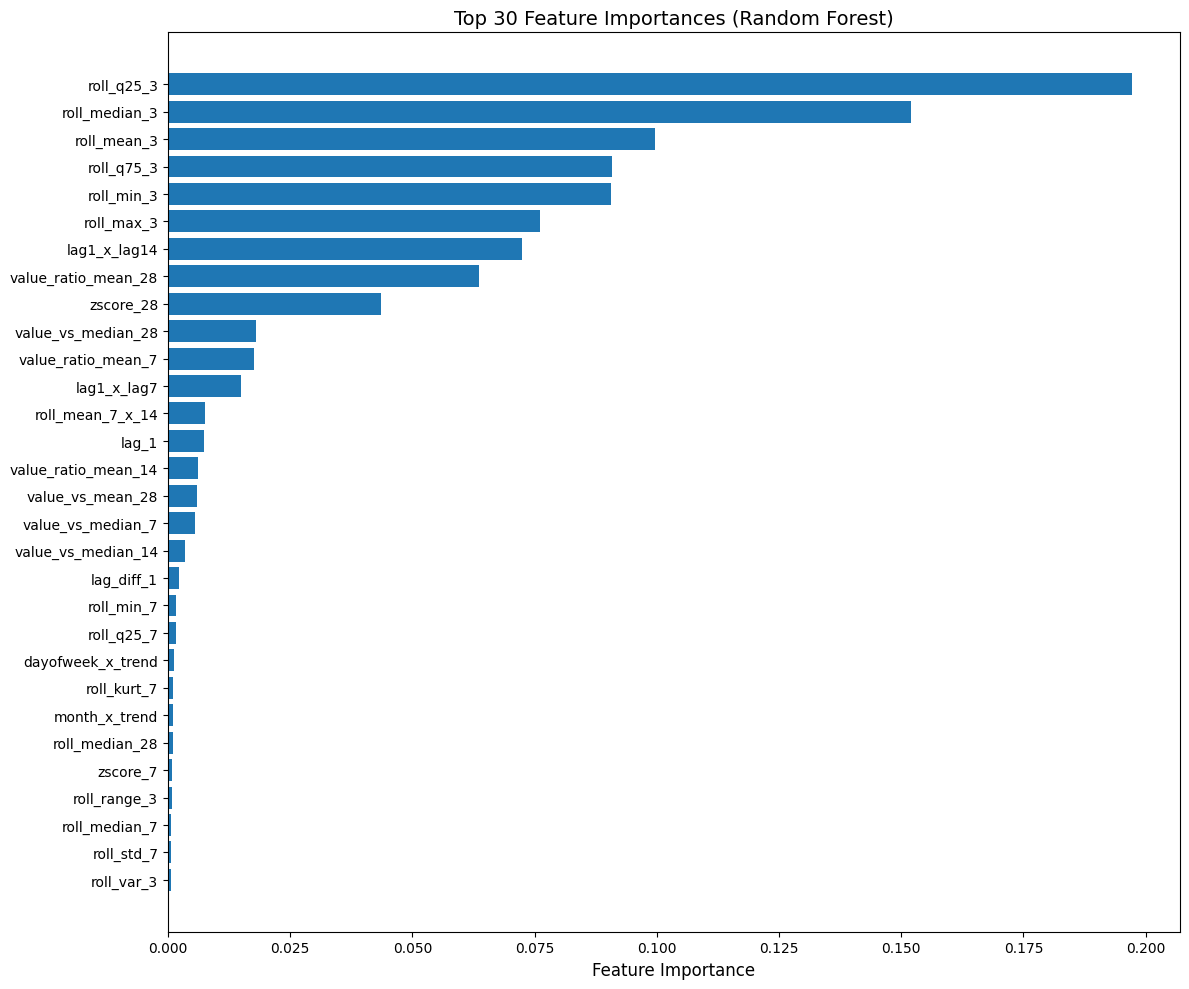


Feature Selection Insights:
  Total features: 122
  Features for 95% cumulative importance: 13
  Features for 99% cumulative importance: 37


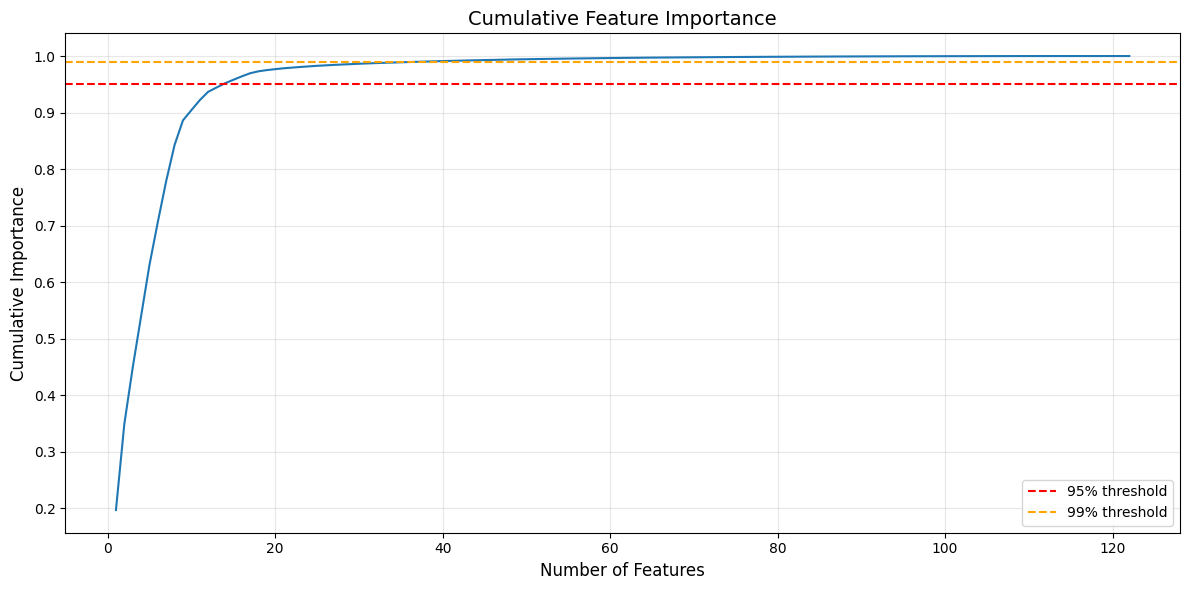


CORRELATION ANALYSIS

Top 15 Features Correlated with Target:
------------------------------------------------------------


roll_mean_3         0.969853
roll_q25_3          0.965820
roll_q75_3          0.962805
roll_median_3       0.961967
roll_max_3          0.953721
roll_min_3          0.950463
roll_mean_7         0.949159
lag1_x_lag7         0.947466
roll_mean_7_x_14    0.943432
roll_median_7       0.941682
roll_q75_7          0.940884
roll_q25_7          0.940469
ewm_lag_3           0.939309
lag1_x_lag14        0.939227
ewm_lag_7           0.938303
dtype: float64


Checking for highly correlated feature pairs (|corr| > 0.95)...
Found 361 highly correlated pairs:
  dayofyear <-> month: 0.996
  quarter <-> month: 0.971
  quarter <-> dayofyear: 0.968
  weekofyear <-> month: 0.974
  weekofyear <-> dayofyear: 0.976
  dayofyear_sin <-> month_sin: 0.956
  dayofyear_cos <-> month_cos: 0.952
  ewm_lag_3 <-> lag_1: 0.985
  ewm_lag_3 <-> lag_2: 0.974
  ewm_lag_3 <-> lag_3: 0.951
  ... and 351 more pairs

RECOMMENDED FEATURE SET: 13 features
This reduced set captures 95% of the feature importance.
You can optionally use these features for faster model training:
  X_train_reduced = X_train[recommended_features]
  X_test_reduced = X_test[recommended_features]


In [50]:
# === Feature Importance Analysis ===
print("=" * 60)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

# Train a quick Random Forest model to get feature importances
from sklearn.ensemble import RandomForestRegressor

# Use a smaller sample for faster feature importance calculation
sample_size = min(1000, len(X_train))
X_train_sample = X_train.iloc[:sample_size]
y_train_sample = y_train.iloc[:sample_size]

print(f"\nTraining Random Forest on {sample_size} samples for feature importance...")
rf_importance = RandomForestRegressor(
    n_estimators=100, 
    max_depth=10, 
    random_state=CONFIG["random_state"], 
    n_jobs=-1
)
rf_importance.fit(X_train_sample, y_train_sample)

# Get feature importances
importances = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_importance.feature_importances_
}).sort_values('importance', ascending=False)

# Display top features
print("\nTop 20 Most Important Features:")
print("-" * 60)
display(importances.head(20))

# Visualize top 30 features
plt.figure(figsize=(12, 10))
top_n = 30
top_features = importances.head(top_n)
plt.barh(range(len(top_features)), top_features['importance'].values)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Feature Importance', fontsize=12)
plt.title(f'Top {top_n} Feature Importances (Random Forest)', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Calculate cumulative importance
importances['cumulative_importance'] = importances['importance'].cumsum()
n_features_95 = (importances['cumulative_importance'] <= 0.95).sum()
n_features_99 = (importances['cumulative_importance'] <= 0.99).sum()

print(f"\nFeature Selection Insights:")
print(f"  Total features: {len(feature_cols)}")
print(f"  Features for 95% cumulative importance: {n_features_95}")
print(f"  Features for 99% cumulative importance: {n_features_99}")

# Plot cumulative importance
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(importances) + 1), importances['cumulative_importance'].values)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.axhline(y=0.99, color='orange', linestyle='--', label='99% threshold')
plt.xlabel('Number of Features', fontsize=12)
plt.ylabel('Cumulative Importance', fontsize=12)
plt.title('Cumulative Feature Importance', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Feature correlation analysis - check for multicollinearity
print("\n" + "=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

# Calculate correlation with target
target_corr = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print("\nTop 15 Features Correlated with Target:")
print("-" * 60)
display(target_corr.head(15))

# Check for highly correlated features (multicollinearity)
print("\nChecking for highly correlated feature pairs (|corr| > 0.95)...")
corr_matrix = X_train.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = []

for column in upper_triangle.columns:
    high_corr = upper_triangle[column][upper_triangle[column] > 0.95]
    if len(high_corr) > 0:
        for idx in high_corr.index:
            high_corr_pairs.append((column, idx, high_corr[idx]))

if high_corr_pairs:
    print(f"Found {len(high_corr_pairs)} highly correlated pairs:")
    for feat1, feat2, corr_val in high_corr_pairs[:10]:  # Show first 10
        print(f"  {feat1} <-> {feat2}: {corr_val:.3f}")
    if len(high_corr_pairs) > 10:
        print(f"  ... and {len(high_corr_pairs) - 10} more pairs")
else:
    print("No highly correlated feature pairs found.")

# Optional: Create a reduced feature set
# Select top N most important features or features up to 95% cumulative importance
recommended_features = importances.head(n_features_95)['feature'].tolist()

print(f"\n" + "=" * 60)
print(f"RECOMMENDED FEATURE SET: {len(recommended_features)} features")
print("=" * 60)
print("This reduced set captures 95% of the feature importance.")
print("You can optionally use these features for faster model training:")
print("  X_train_reduced = X_train[recommended_features]")
print("  X_test_reduced = X_test[recommended_features]")
print("=" * 60)

## 4) exploration_analysis

EXPLORATORY DATA ANALYSIS

[1/10] Descriptive Statistics
--------------------------------------------------------------------------------


count      2832.000000
mean     107582.942653
std       23822.624093
min           0.063063
25%       90900.461712
50%      104662.905405
75%      121109.301802
max      170046.828829
Name: value, dtype: float64


Key Insights:
  Range: [0.06, 170046.83]
  IQR: 30208.84
  Coefficient of Variation: 22.14%
  Skewness: 0.333 (right-skewed)
  Kurtosis: -0.434 (light-tailed)

[2/10] Time Series Plot
--------------------------------------------------------------------------------


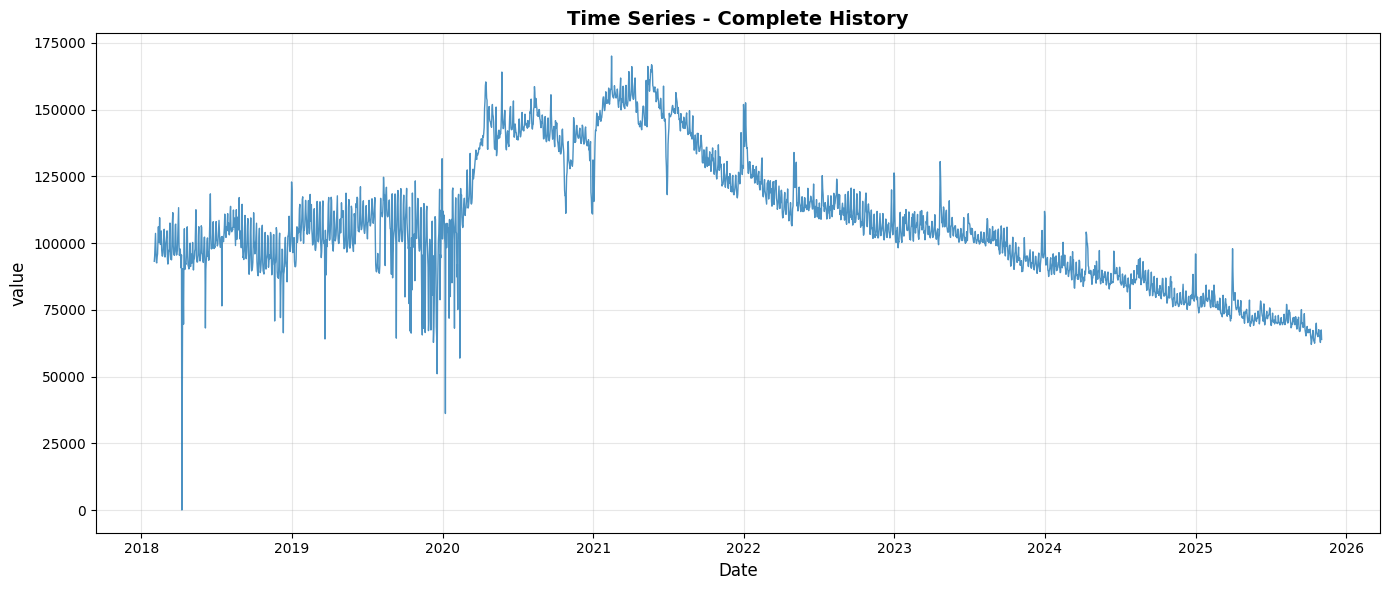


[3/10] Distribution Analysis
--------------------------------------------------------------------------------


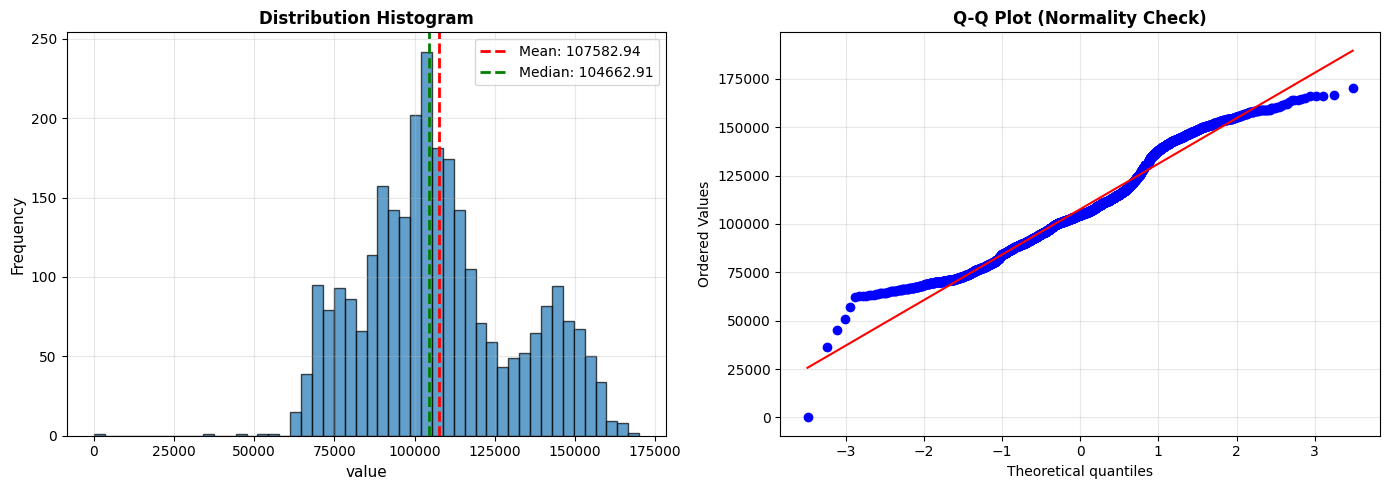

Shapiro-Wilk normality test p-value: 0.000000
  → Data is NOT normally distributed (α=0.05)

[4/10] Trend Analysis
--------------------------------------------------------------------------------


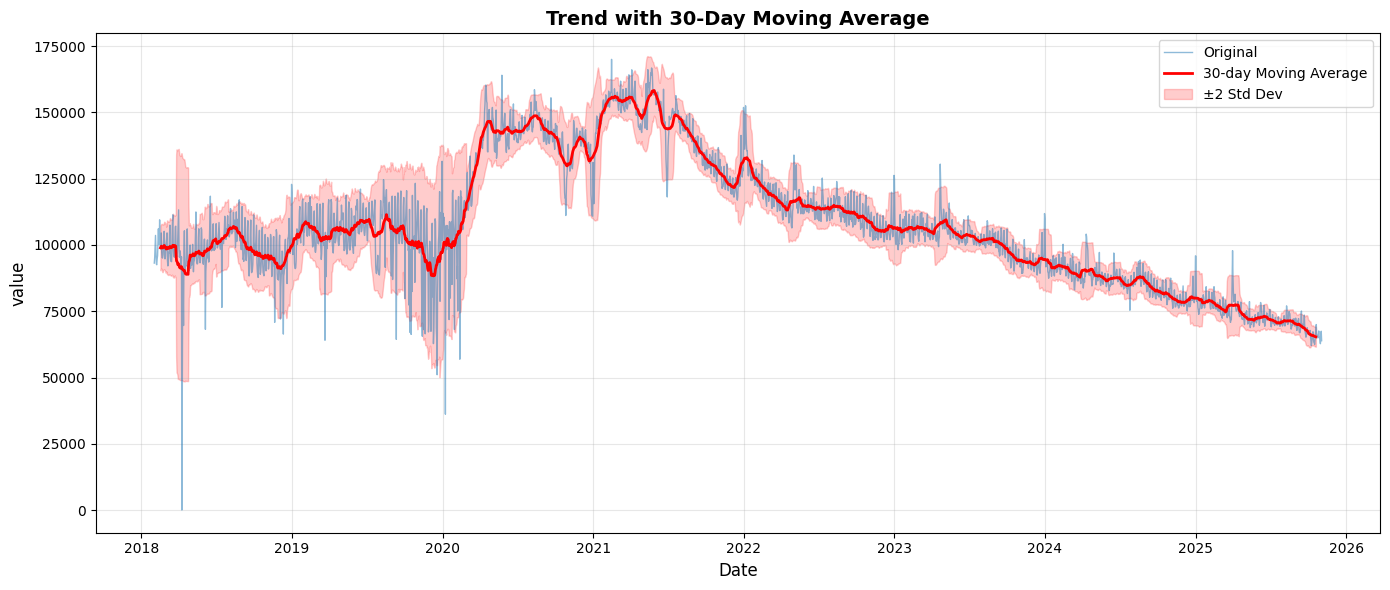


[5/10] Monthly Seasonality Pattern
--------------------------------------------------------------------------------


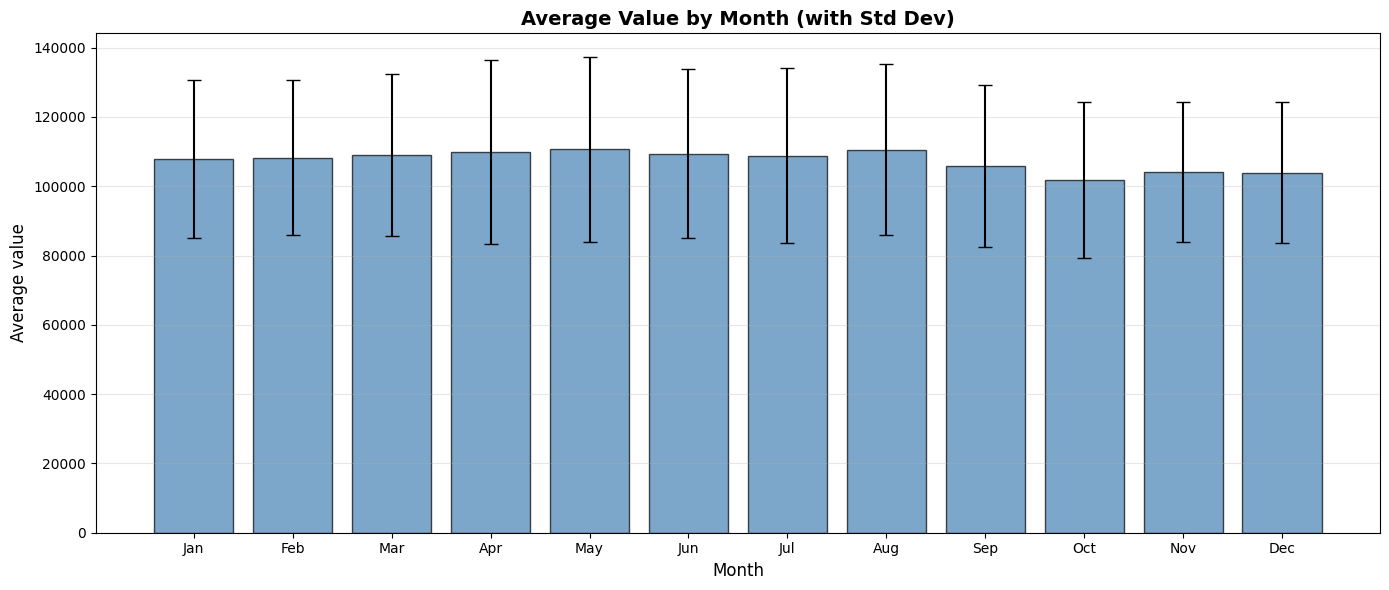


[6/10] Weekly Seasonality Pattern
--------------------------------------------------------------------------------


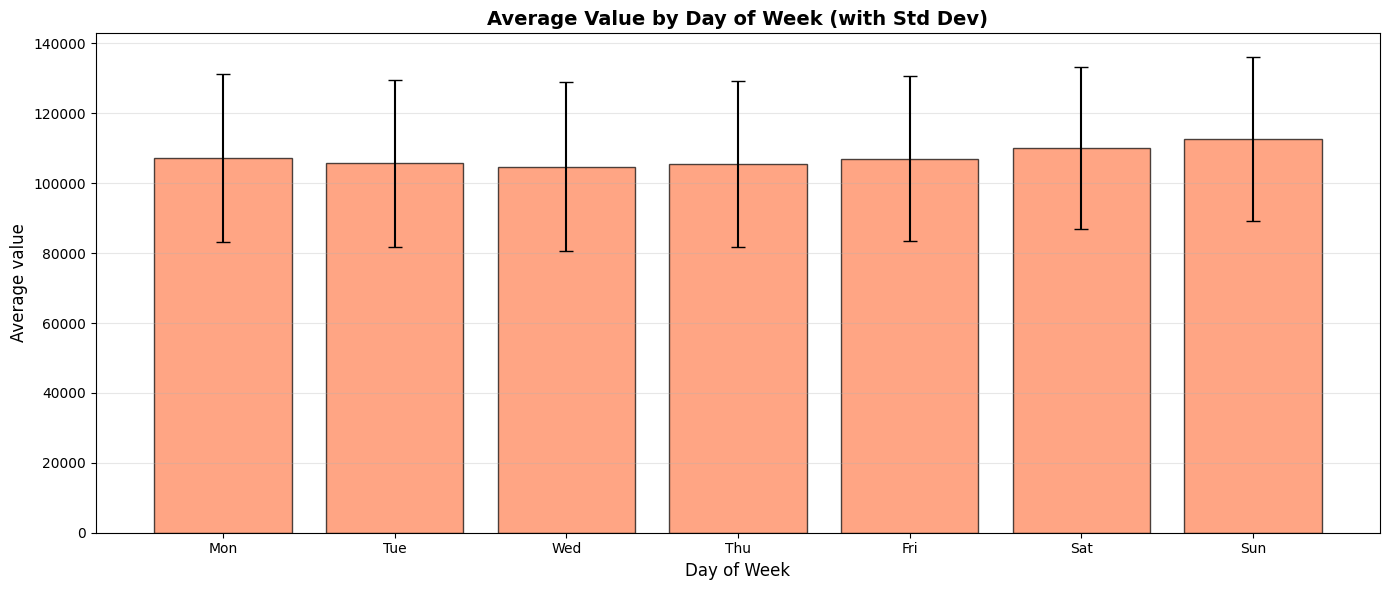


[7/10] Autocorrelation Analysis (ACF)
--------------------------------------------------------------------------------


<Figure size 1400x600 with 0 Axes>

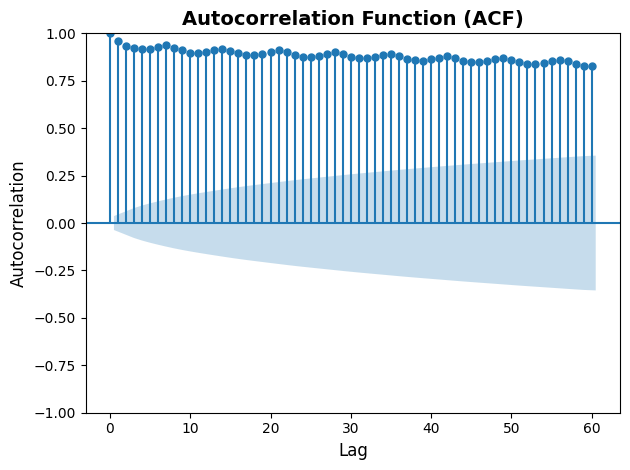

Interpretation:
  - Significant spikes indicate correlation with past values at those lags
  - Slowly decaying ACF suggests trend/non-stationarity
  - Repeating patterns suggest seasonality

[8/10] Partial Autocorrelation Analysis (PACF)
--------------------------------------------------------------------------------


<Figure size 1400x600 with 0 Axes>

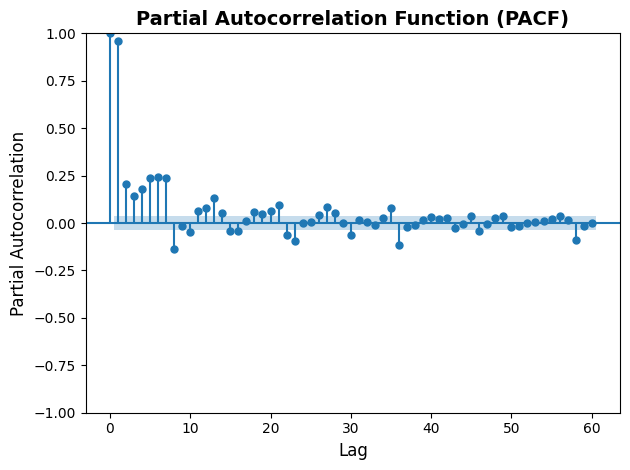

Interpretation:
  - PACF helps identify the order of AR terms
  - Significant spikes suggest direct relationship at those lags

[9/10] Seasonal Decomposition
--------------------------------------------------------------------------------


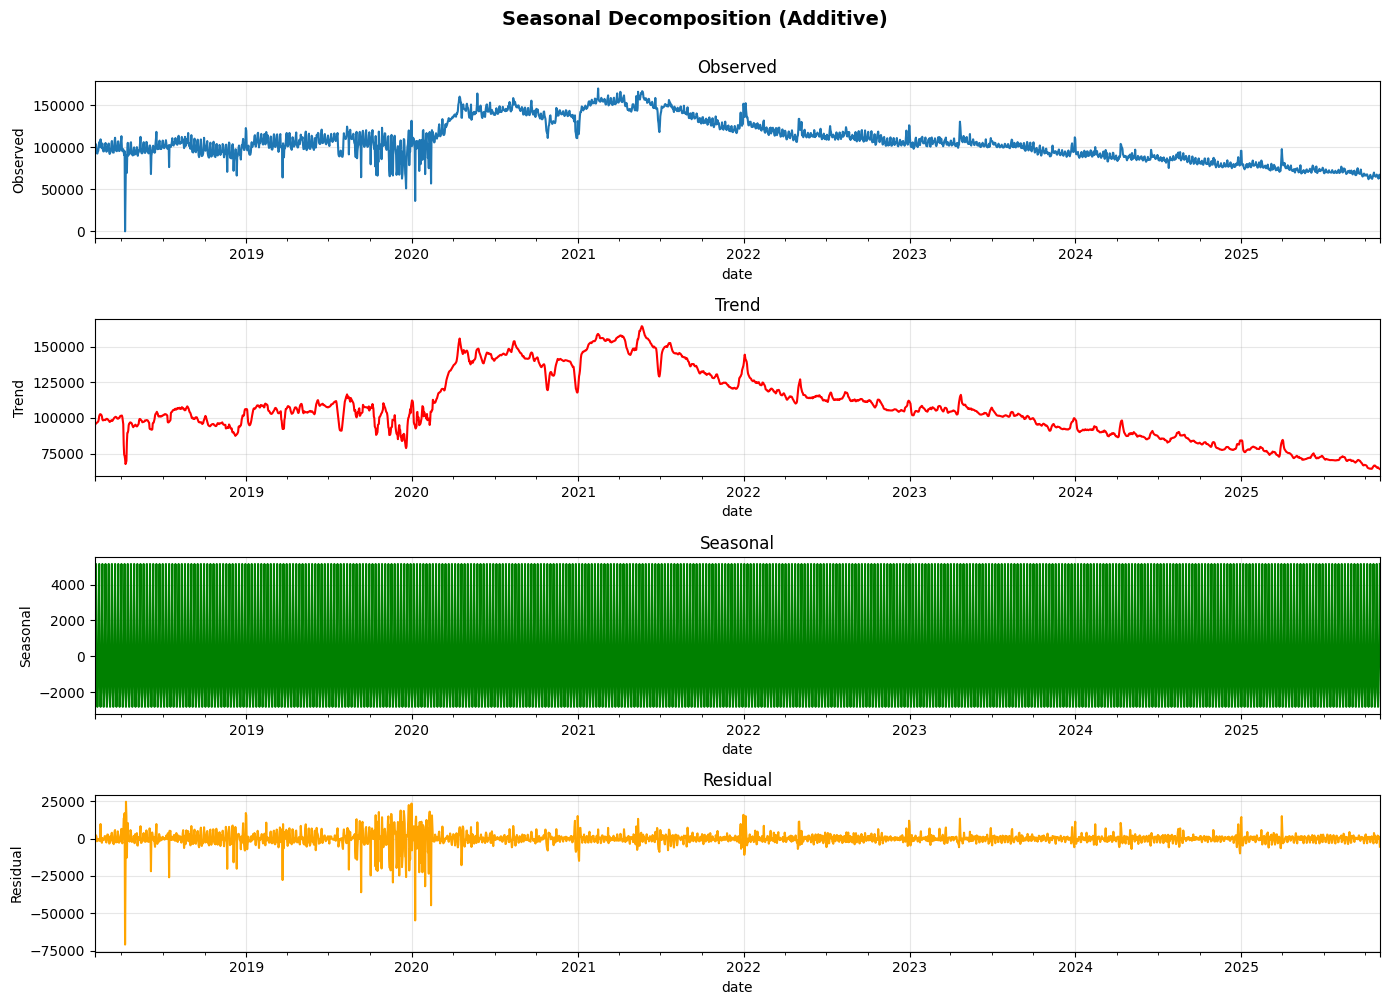


Decomposition Metrics:
  Trend Strength: 0.254 (Weak)
  Seasonal Strength: 0.963 (Strong)

[10/10] Stationarity Test (Augmented Dickey-Fuller)
--------------------------------------------------------------------------------
ADF Statistic: -0.560856
p-value: 0.879584
Critical Values:
  1%: -3.433
  5%: -2.863
  10%: -2.567

  → Series is NON-STATIONARY (p-value >= 0.05)
     Consider differencing for ARIMA-type models

  First Difference ADF p-value: 0.000000
  → First difference is stationary (d=1 for ARIMA)

EXPLORATORY ANALYSIS COMPLETE


In [51]:
# === COMPREHENSIVE EXPLORATORY ANALYSIS ===
print("=" * 80)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 80)

# 1. Basic Statistics
print("\n[1/10] Descriptive Statistics")
print("-" * 80)
stats = raw[target_col].describe()
display(stats)

print(f"\nKey Insights:")
print(f"  Range: [{stats['min']:.2f}, {stats['max']:.2f}]")
print(f"  IQR: {stats['75%'] - stats['25%']:.2f}")
print(f"  Coefficient of Variation: {(stats['std'] / stats['mean']) * 100:.2f}%")

# Calculate additional statistics
from scipy import stats as scipy_stats
skewness = scipy_stats.skew(raw[target_col].dropna())
kurtosis = scipy_stats.kurtosis(raw[target_col].dropna())
print(f"  Skewness: {skewness:.3f} {'(right-skewed)' if skewness > 0 else '(left-skewed)' if skewness < 0 else '(symmetric)'}")
print(f"  Kurtosis: {kurtosis:.3f} {'(heavy-tailed)' if kurtosis > 0 else '(light-tailed)'}")

# 2. Time Series Plot
print("\n[2/10] Time Series Plot")
print("-" * 80)
plt.figure(figsize=(14, 6))
plt.plot(raw[raw.columns[0]], raw[target_col], linewidth=1, alpha=0.8)
plt.title("Time Series - Complete History", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel(target_col, fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Distribution Analysis
print("\n[3/10] Distribution Analysis")
print("-" * 80)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(raw[target_col].dropna(), bins=50, edgecolor='black', alpha=0.7)
plt.axvline(raw[target_col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {raw[target_col].mean():.2f}')
plt.axvline(raw[target_col].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {raw[target_col].median():.2f}')
plt.title("Distribution Histogram", fontsize=12, fontweight='bold')
plt.xlabel(target_col, fontsize=11)
plt.ylabel("Frequency", fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
scipy_stats.probplot(raw[target_col].dropna(), dist="norm", plot=plt)
plt.title("Q-Q Plot (Normality Check)", fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Normality test
from scipy.stats import shapiro
if len(raw[target_col].dropna()) <= 5000:
    _, p_value = shapiro(raw[target_col].dropna())
    print(f"Shapiro-Wilk normality test p-value: {p_value:.6f}")
    print(f"  → Data is {'NOT normally distributed' if p_value < 0.05 else 'approximately normally distributed'} (α=0.05)")

# 4. Trend Analysis
print("\n[4/10] Trend Analysis")
print("-" * 80)

# Calculate rolling statistics
window = 30
rolling_mean = raw[target_col].rolling(window=window, center=True).mean()
rolling_std = raw[target_col].rolling(window=window, center=True).std()

plt.figure(figsize=(14, 6))
plt.plot(raw[raw.columns[0]], raw[target_col], label='Original', alpha=0.5, linewidth=1)
plt.plot(raw[raw.columns[0]], rolling_mean, label=f'{window}-day Moving Average', color='red', linewidth=2)
plt.fill_between(raw[raw.columns[0]], 
                 rolling_mean - 2*rolling_std, 
                 rolling_mean + 2*rolling_std, 
                 alpha=0.2, color='red', label='±2 Std Dev')
plt.title(f"Trend with {window}-Day Moving Average", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel(target_col, fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Seasonality Patterns - Month
print("\n[5/10] Monthly Seasonality Pattern")
print("-" * 80)
raw_temp = raw.copy()
raw_temp['month'] = pd.to_datetime(raw_temp[raw_temp.columns[0]]).dt.month
monthly_stats = raw_temp.groupby('month')[target_col].agg(['mean', 'std', 'count'])

plt.figure(figsize=(14, 6))
months = monthly_stats.index
plt.bar(months, monthly_stats['mean'], yerr=monthly_stats['std'], 
        alpha=0.7, capsize=5, color='steelblue', edgecolor='black')
plt.title("Average Value by Month (with Std Dev)", fontsize=14, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel(f"Average {target_col}", fontsize=12)
plt.xticks(months, ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 6. Seasonality Patterns - Day of Week
print("\n[6/10] Weekly Seasonality Pattern")
print("-" * 80)
raw_temp['dayofweek'] = pd.to_datetime(raw_temp[raw_temp.columns[0]]).dt.dayofweek
dow_stats = raw_temp.groupby('dayofweek')[target_col].agg(['mean', 'std', 'count'])

plt.figure(figsize=(14, 6))
days = dow_stats.index
plt.bar(days, dow_stats['mean'], yerr=dow_stats['std'], 
        alpha=0.7, capsize=5, color='coral', edgecolor='black')
plt.title("Average Value by Day of Week (with Std Dev)", fontsize=14, fontweight='bold')
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel(f"Average {target_col}", fontsize=12)
plt.xticks(days, ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 7. Autocorrelation Analysis
print("\n[7/10] Autocorrelation Analysis (ACF)")
print("-" * 80)
from statsmodels.graphics.tsaplots import plot_acf
plt.figure(figsize=(14, 6))
plot_acf(raw[target_col].dropna(), lags=min(60, len(raw)//2), alpha=0.05)
plt.title("Autocorrelation Function (ACF)", fontsize=14, fontweight='bold')
plt.xlabel("Lag", fontsize=12)
plt.ylabel("Autocorrelation", fontsize=12)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  - Significant spikes indicate correlation with past values at those lags")
print("  - Slowly decaying ACF suggests trend/non-stationarity")
print("  - Repeating patterns suggest seasonality")

# 8. Partial Autocorrelation Analysis
print("\n[8/10] Partial Autocorrelation Analysis (PACF)")
print("-" * 80)
from statsmodels.graphics.tsaplots import plot_pacf
plt.figure(figsize=(14, 6))
plot_pacf(raw[target_col].dropna(), lags=min(60, len(raw)//2), method="ywm", alpha=0.05)
plt.title("Partial Autocorrelation Function (PACF)", fontsize=14, fontweight='bold')
plt.xlabel("Lag", fontsize=12)
plt.ylabel("Partial Autocorrelation", fontsize=12)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  - PACF helps identify the order of AR terms")
print("  - Significant spikes suggest direct relationship at those lags")

# 9. Seasonal Decomposition
print("\n[9/10] Seasonal Decomposition")
print("-" * 80)
try:
    from statsmodels.tsa.seasonal import seasonal_decompose
    
    # Prepare series with proper frequency
    series_indexed = raw.set_index(raw.columns[0])[target_col]
    freq = pd.infer_freq(series_indexed.index)
    if freq:
        series_indexed = series_indexed.asfreq(freq)
    
    # Additive decomposition
    decomposition = seasonal_decompose(series_indexed, model='additive', period=7, extrapolate_trend='freq')
    
    fig, axes = plt.subplots(4, 1, figsize=(14, 10))
    
    # Observed
    decomposition.observed.plot(ax=axes[0], title='Observed', legend=False)
    axes[0].set_ylabel('Observed')
    axes[0].grid(True, alpha=0.3)
    
    # Trend
    decomposition.trend.plot(ax=axes[1], title='Trend', legend=False, color='red')
    axes[1].set_ylabel('Trend')
    axes[1].grid(True, alpha=0.3)
    
    # Seasonal
    decomposition.seasonal.plot(ax=axes[2], title='Seasonal', legend=False, color='green')
    axes[2].set_ylabel('Seasonal')
    axes[2].grid(True, alpha=0.3)
    
    # Residual
    decomposition.resid.plot(ax=axes[3], title='Residual', legend=False, color='orange')
    axes[3].set_ylabel('Residual')
    axes[3].grid(True, alpha=0.3)
    
    plt.suptitle('Seasonal Decomposition (Additive)', fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
    
    # Calculate strength of trend and seasonality
    var_resid = np.var(decomposition.resid.dropna())
    var_detrend = np.var((decomposition.observed - decomposition.trend).dropna())
    var_deseason = np.var((decomposition.observed - decomposition.seasonal).dropna())
    
    trend_strength = max(0, 1 - var_resid / var_detrend)
    seasonal_strength = max(0, 1 - var_resid / var_deseason)
    
    print(f"\nDecomposition Metrics:")
    print(f"  Trend Strength: {trend_strength:.3f} {'(Strong)' if trend_strength > 0.6 else '(Moderate)' if trend_strength > 0.3 else '(Weak)'}")
    print(f"  Seasonal Strength: {seasonal_strength:.3f} {'(Strong)' if seasonal_strength > 0.6 else '(Moderate)' if seasonal_strength > 0.3 else '(Weak)'}")
    
except Exception as e:
    print(f"Seasonal decomposition failed: {e}")

# 10. Stationarity Test
print("\n[10/10] Stationarity Test (Augmented Dickey-Fuller)")
print("-" * 80)
from statsmodels.tsa.stattools import adfuller

result = adfuller(raw[target_col].dropna())
print(f"ADF Statistic: {result[0]:.6f}")
print(f"p-value: {result[1]:.6f}")
print(f"Critical Values:")
for key, value in result[4].items():
    print(f"  {key}: {value:.3f}")

if result[1] < 0.05:
    print(f"\n  → Series is STATIONARY (p-value < 0.05)")
    print(f"     No differencing needed for modeling")
else:
    print(f"\n  → Series is NON-STATIONARY (p-value >= 0.05)")
    print(f"     Consider differencing for ARIMA-type models")
    
    # Test first difference
    diff = raw[target_col].diff().dropna()
    result_diff = adfuller(diff)
    print(f"\n  First Difference ADF p-value: {result_diff[1]:.6f}")
    if result_diff[1] < 0.05:
        print(f"  → First difference is stationary (d=1 for ARIMA)")
    else:
        print(f"  → May need higher order differencing (d>1 for ARIMA)")

print("\n" + "=" * 80)
print("EXPLORATORY ANALYSIS COMPLETE")
print("=" * 80)

## 5) base_model

In [21]:
# Naive (last value) and Seasonal Naive (last value of same season)
train_idx_end = train.index[-1]
history = raw.set_index(raw.columns[0])[target_col]

# Align to test index
test_index = test[train.columns[0]] if train.columns[0] == raw.columns[0] else test[raw.columns[0]]

# Naive forecast: last observed value
last_val = history.loc[:test_index.min()].iloc[-1]
yhat_naive = np.full(shape=len(test_index), fill_value=last_val)

# Seasonal naive using first seasonal_period available
sp = CONFIG["seasonal_periods"][0] if CONFIG["seasonal_periods"] else None
if sp and len(history) > sp:
    yhat_snaive = history.iloc[-sp:]
    # repeat to length of test
    reps = int(np.ceil(len(test_index) / sp))
    yhat_snaive = np.tile(yhat_snaive.values, reps)[:len(test_index)]
else:
    yhat_snaive = yhat_naive.copy()

print("Base models built.")

Base models built.


## 6) statistical_models

In [22]:
# === Exponential Smoothing with Hyperparameter Tuning ===
hw_model = None
best_hw_params = {}

if CONFIG["enable_hyperparameter_tuning"]:
    print("Tuning Exponential Smoothing...")
    series_train = train.set_index(train.columns[0])[target_col]
    
    # Grid search over trend, seasonal, and damping parameters
    best_aic = np.inf
    param_grid = {
        'trend': ['add', 'mul', None],
        'seasonal': ['add', 'mul', None],
        'damped_trend': [True, False]
    }
    
    sp = CONFIG["seasonal_periods"][0] if CONFIG["seasonal_periods"] else None
    
    for trend in param_grid['trend']:
        for seasonal in param_grid['seasonal']:
            for damped in param_grid['damped_trend']:
                try:
                    # Skip invalid combinations
                    if damped and trend is None:
                        continue
                    if seasonal and not sp:
                        continue
                    
                    model = ExponentialSmoothing(
                        series_train, 
                        trend=trend, 
                        seasonal=seasonal, 
                        seasonal_periods=sp,
                        damped_trend=damped
                    ).fit(optimized=True)
                    
                    if model.aic < best_aic:
                        best_aic = model.aic
                        best_hw_params = {
                            'trend': trend, 
                            'seasonal': seasonal, 
                            'damped_trend': damped,
                            'aic': model.aic
                        }
                        hw_model = model
                except Exception:
                    continue
    
    print(f"Best HW params: {best_hw_params}")
    yhat_hw = hw_model.forecast(len(test))
else:
    # Default configuration
    try:
        seasonal = 'add' if CONFIG["seasonal_periods"] else None
        sp = CONFIG["seasonal_periods"][0] if CONFIG["seasonal_periods"] else None
        series_train = train.set_index(train.columns[0])[target_col]
        hw_model = ExponentialSmoothing(series_train, trend='add', seasonal=seasonal, seasonal_periods=sp).fit()
        yhat_hw = hw_model.forecast(len(test))
    except Exception as e:
        print("HW model failed:", e)
        yhat_hw = np.full(len(test), series_train.iloc[-1])

# === SARIMAX with Grid Search ===
def tune_sarimax(endog, seasonal_periods=None, p_range=(0,3), d_range=(0,2), q_range=(0,3), 
                 P_range=(0,2), D_range=(0,2), Q_range=(0,2)):
    """
    Comprehensive SARIMAX hyperparameter tuning using grid search.
    Returns best model and parameters based on AIC.
    """
    best_aic, best_order, best_seasonal = np.inf, None, None
    best_model = None
    total_configs = 0
    
    for p in range(p_range[0], p_range[1]):
        for d in range(d_range[0], d_range[1]):
            for q in range(q_range[0], q_range[1]):
                order = (p, d, q)
                
                if seasonal_periods:
                    for P in range(P_range[0], P_range[1]):
                        for D in range(D_range[0], D_range[1]):
                            for Q in range(Q_range[0], Q_range[1]):
                                seasonal_order = (P, D, Q, seasonal_periods)
                                try:
                                    model = SARIMAX(
                                        endog, 
                                        order=order, 
                                        seasonal_order=seasonal_order, 
                                        enforce_stationarity=False, 
                                        enforce_invertibility=False
                                    )
                                    res = model.fit(disp=False, maxiter=200)
                                    total_configs += 1
                                    
                                    if res.aic < best_aic:
                                        best_aic, best_order, best_seasonal = res.aic, order, seasonal_order
                                        best_model = res
                                except Exception:
                                    continue
                else:
                    try:
                        model = SARIMAX(endog, order=order, enforce_stationarity=False, enforce_invertibility=False)
                        res = model.fit(disp=False, maxiter=200)
                        total_configs += 1
                        
                        if res.aic < best_aic:
                            best_aic, best_order, best_seasonal = res.aic, order, None
                            best_model = res
                    except Exception:
                        continue
    
    print(f"Tested {total_configs} SARIMAX configurations")
    return best_model, best_order, best_seasonal, best_aic

series_train = train.set_index(train.columns[0])[target_col].astype(float)

if CONFIG["enable_hyperparameter_tuning"]:
    print("Tuning SARIMAX (this may take a few minutes)...")
    sp = CONFIG["seasonal_periods"][0] if CONFIG["seasonal_periods"] else None
    sarimax_model, order, seasonal_order, aic = tune_sarimax(
        series_train, 
        seasonal_periods=sp,
        p_range=(0, 3), d_range=(0, 2), q_range=(0, 3),
        P_range=(0, 2), D_range=(0, 2), Q_range=(0, 2)
    )
    print(f"Best SARIMAX: order={order}, seasonal_order={seasonal_order}, AIC={aic:.2f}")
else:
    # Simple auto selection (faster)
    def auto_sarimax_simple(endog, seasonal_periods=None):
        best_aic, best_order, best_seasonal = np.inf, None, None
        for p in range(3):
            for d in range(2):
                for q in range(3):
                    order = (p, d, q)
                    if seasonal_periods:
                        seasonal_order = (1, 0, 1, seasonal_periods)
                        try:
                            model = SARIMAX(endog, order=order, seasonal_order=seasonal_order, 
                                          enforce_stationarity=False, enforce_invertibility=False)
                            res = model.fit(disp=False)
                            if res.aic < best_aic:
                                best_aic, best_order, best_seasonal = res.aic, order, seasonal_order
                        except Exception:
                            continue
                    else:
                        try:
                            model = SARIMAX(endog, order=order, enforce_stationarity=False, 
                                          enforce_invertibility=False)
                            res = model.fit(disp=False)
                            if res.aic < best_aic:
                                best_aic, best_order, best_seasonal = res.aic, order, None
                        except Exception:
                            continue
        return best_order, best_seasonal
    
    sp = CONFIG["seasonal_periods"][0] if CONFIG["seasonal_periods"] else None
    order, seasonal_order = auto_sarimax_simple(series_train, seasonal_periods=sp)
    print("Chosen SARIMAX orders:", order, seasonal_order)
    sarimax_model = SARIMAX(series_train, order=order, seasonal_order=seasonal_order, 
                           enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

try:
    yhat_sarimax = sarimax_model.forecast(steps=len(test)).values
except Exception as e:
    print("SARIMAX forecast failed:", e)
    yhat_sarimax = np.full(len(test), series_train.iloc[-1])

Tuning Exponential Smoothing...
Best HW params: {'trend': None, 'seasonal': 'add', 'damped_trend': False, 'aic': 39167.05093302304}
Tuning SARIMAX (this may take a few minutes)...
Tested 144 SARIMAX configurations
Best SARIMAX: order=(1, 1, 1), seasonal_order=(1, 1, 1, 7), AIC=45293.73


## 7.5) prophet_model

In [39]:
# === ML Models with Hyperparameter Tuning ===

# Linear Regression (no hyperparameters to tune)
lin = LinearRegression()
lin.fit(X_train, y_train)
yhat_lin = lin.predict(X_test)
print("Linear Regression trained (no hyperparameters to tune)")

# === Random Forest with Grid Search ===
if CONFIG["enable_hyperparameter_tuning"]:
    print("Tuning Random Forest...")
    
    # Define parameter grid
    rf_param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    }
    
    # Use TimeSeriesSplit for cross-validation
    tscv = TimeSeriesSplit(n_splits=CONFIG["n_splits"])
    
    # Create scorer
    def neg_rmse(y_true, y_pred):
        return -np.sqrt(mean_squared_error(y_true, y_pred))
    
    scorer = make_scorer(neg_rmse)
    
    # Grid search
    rf_base = RandomForestRegressor(random_state=CONFIG["random_state"], n_jobs=-1)
    rf_grid = GridSearchCV(
        rf_base, 
        rf_param_grid, 
        cv=tscv, 
        scoring=scorer, 
        n_jobs=-1,
        verbose=0
    )
    rf_grid.fit(X_train, y_train)
    
    print(f"Best RF params: {rf_grid.best_params_}")
    print(f"Best RF CV score (neg RMSE): {rf_grid.best_score_:.2f}")
    
    rf = rf_grid.best_estimator_
    yhat_rf = rf.predict(X_test)
else:
    # Default configuration
    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=CONFIG["random_state"],
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    yhat_rf = rf.predict(X_test)
    print("Random Forest trained with default parameters")

# === Gradient Boosting with Grid Search ===
if CONFIG["enable_hyperparameter_tuning"]:
    print("Tuning Gradient Boosting...")
    
    gb_param_grid = {
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
    }
    
    gb_base = GradientBoostingRegressor(random_state=CONFIG["random_state"])
    gb_grid = GridSearchCV(
        gb_base, 
        gb_param_grid, 
        cv=tscv, 
        scoring=scorer, 
        n_jobs=-1,
        verbose=0
    )
    gb_grid.fit(X_train, y_train)
    
    print(f"Best GB params: {gb_grid.best_params_}")
    print(f"Best GB CV score (neg RMSE): {gb_grid.best_score_:.2f}")
    
    gb = gb_grid.best_estimator_
    yhat_gb = gb.predict(X_test)
else:
    # Default configuration
    gb = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        random_state=CONFIG["random_state"]
    )
    gb.fit(X_train, y_train)
    yhat_gb = gb.predict(X_test)
    print("Gradient Boosting trained with default parameters")

print("\nML models trained.")

Linear Regression trained (no hyperparameters to tune)
Tuning Random Forest...


KeyboardInterrupt: 

## 7.5) prophet_model

Training Prophet model...
Tuning Prophet hyperparameters...


20:04:53 - cmdstanpy - INFO - Chain [1] start processing


Tested 96 Prophet configurations
Best Prophet params: {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive', 'changepoint_range': 0.8}
Best CV RMSE: inf


20:04:54 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully


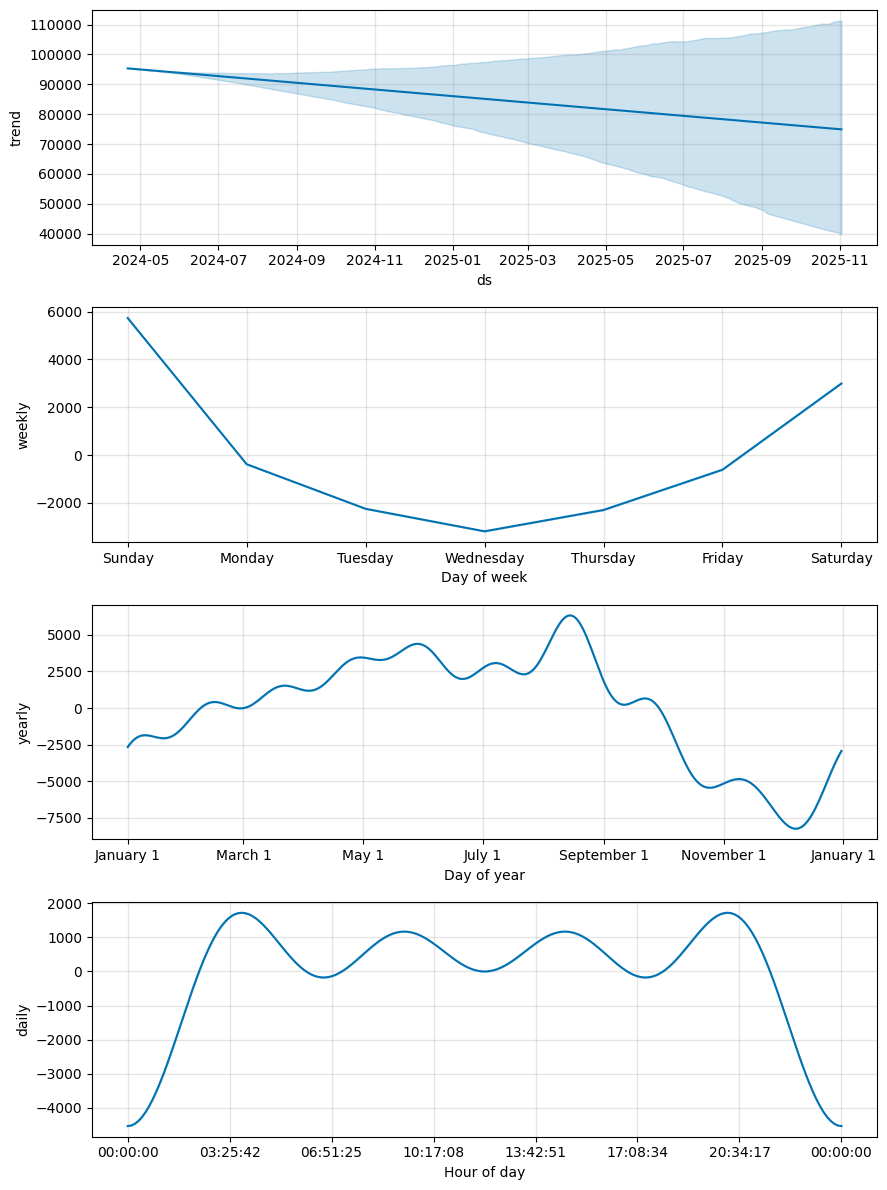

In [41]:
# === Prophet Model with Hyperparameter Tuning ===
yhat_prophet = None

if PROPHET_AVAILABLE:
    print("Training Prophet model...")
    
    # Prepare data in Prophet format (requires 'ds' and 'y' columns)
    prophet_train = train[[train.columns[0], target_col]].copy()
    prophet_train.columns = ['ds', 'y']
    
    prophet_test = test[[test.columns[0], target_col]].copy()
    prophet_test.columns = ['ds', 'y']
    
    if CONFIG["enable_hyperparameter_tuning"]:
        print("Tuning Prophet hyperparameters...")
        
        # Define parameter grid for Prophet
        prophet_param_grid = {
            'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
            'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
            'seasonality_mode': ['additive', 'multiplicative'],
            'changepoint_range': [0.8, 0.9, 0.95]
        }
        
        # Manual grid search with cross-validation
        best_rmse = np.inf
        best_prophet_params = {}
        best_prophet_model = None
        
        # Use time series cross-validation
        tscv = TimeSeriesSplit(n_splits=min(3, CONFIG["n_splits"]))  # Fewer splits for speed
        
        total_configs = 0
        for cps in prophet_param_grid['changepoint_prior_scale']:
            for sps in prophet_param_grid['seasonality_prior_scale']:
                for sm in prophet_param_grid['seasonality_mode']:
                    for cr in prophet_param_grid['changepoint_range']:
                        cv_scores = []
                        
                        for train_idx, val_idx in tscv.split(prophet_train):
                            try:
                                # Split data
                                train_cv = prophet_train.iloc[train_idx]
                                val_cv = prophet_train.iloc[val_idx]
                                
                                # Train model
                                m = Prophet(
                                    changepoint_prior_scale=cps,
                                    seasonality_prior_scale=sps,
                                    seasonality_mode=sm,
                                    changepoint_range=cr,
                                    daily_seasonality=True,
                                    weekly_seasonality=True,
                                    yearly_seasonality=True
                                )
                                m.fit(train_cv, disable_tqdm=True)
                                
                                # Predict on validation
                                future = val_cv[['ds']].copy()
                                forecast = m.predict(future)
                                
                                # Calculate RMSE
                                rmse_val = np.sqrt(mean_squared_error(val_cv['y'], forecast['yhat']))
                                cv_scores.append(rmse_val)
                            except Exception:
                                cv_scores.append(np.inf)
                        
                        # Average CV score
                        avg_rmse = np.mean(cv_scores)
                        total_configs += 1
                        
                        if avg_rmse < best_rmse:
                            best_rmse = avg_rmse
                            best_prophet_params = {
                                'changepoint_prior_scale': cps,
                                'seasonality_prior_scale': sps,
                                'seasonality_mode': sm,
                                'changepoint_range': cr
                            }
        
        print(f"Tested {total_configs} Prophet configurations")
        
        # Check if grid search found valid parameters
        if not best_prophet_params:
            print("WARNING: Grid search failed to find valid parameters. Using defaults.")
            best_prophet_params = {
                'changepoint_prior_scale': 0.05,
                'seasonality_prior_scale': 10.0,
                'seasonality_mode': 'additive',
                'changepoint_range': 0.8
            }
            best_rmse = np.inf
        
        print(f"Best Prophet params: {best_prophet_params}")
        print(f"Best CV RMSE: {best_rmse:.2f}")
        
        # Train final model with best parameters
        best_prophet_model = Prophet(
            changepoint_prior_scale=best_prophet_params['changepoint_prior_scale'],
            seasonality_prior_scale=best_prophet_params['seasonality_prior_scale'],
            seasonality_mode=best_prophet_params['seasonality_mode'],
            changepoint_range=best_prophet_params['changepoint_range'],
            daily_seasonality=True,
            weekly_seasonality=True,
            yearly_seasonality=True
        )
        best_prophet_model.fit(prophet_train)
        
        # Make predictions
        future = prophet_test[['ds']].copy()
        forecast = best_prophet_model.predict(future)
        yhat_prophet = forecast['yhat'].values
        
    else:
        # Default Prophet configuration
        print("Training Prophet with default parameters...")
        m = Prophet(
            daily_seasonality=True,
            weekly_seasonality=True,
            yearly_seasonality=True
        )
        m.fit(prophet_train)
        
        # Make predictions
        future = prophet_test[['ds']].copy()
        forecast = m.predict(future)
        yhat_prophet = forecast['yhat'].values
        best_prophet_model = m
    
    print("Prophet model trained successfully")
    
    # Optional: Plot Prophet forecast components
    try:
        fig = best_prophet_model.plot_components(forecast)
        plt.show()
    except Exception as e:
        print(f"Could not plot Prophet components: {e}")
        
else:
    print("Prophet not available - skipping. Install with: pip install prophet")
    yhat_prophet = np.full(len(test), np.nan)

In [42]:
# === Ensemble Models ===
# Combine predictions from all models using simple averaging and weighted ensemble

# Collect all predictions
preds = [
    yhat_naive,
    yhat_snaive,
    np.asarray(yhat_hw),
    np.asarray(yhat_sarimax),
    yhat_lin,
    yhat_rf,
    yhat_gb,  # Added Gradient Boosting
]

# Add Prophet if available
if PROPHET_AVAILABLE and yhat_prophet is not None:
    preds.append(np.asarray(yhat_prophet))
    print("Including Prophet in ensemble")

# Ensure all predictions have the same shape
preds = [np.asarray(p).reshape(-1) for p in preds]

# Simple averaging ensemble
Y = np.vstack(preds).T
yhat_ens_mean = np.nanmean(Y, axis=1)

# Weighted ensemble based on inverse RMSE on training data
# Calculate weights using a small holdout from training data for validation
if len(train) > 100:
    val_size = min(100, len(train) // 5)
    train_subset = train.iloc[:-val_size]
    val_subset = train.iloc[-val_size:]
    
    X_train_sub = train_subset[feature_cols]
    y_train_sub = train_subset[target_col]
    X_val = val_subset[feature_cols]
    y_val = val_subset[target_col]
    
    # Get predictions on validation set for ML models
    weights = []
    
    try:
        # Naive
        last_val_naive = train_subset[target_col].iloc[-1]
        pred_naive = np.full(len(y_val), last_val_naive)
        rmse_naive = rmse(y_val, pred_naive)
        weights.append(1.0 / (rmse_naive + 1e-6))
    except:
        weights.append(0.001)
    
    try:
        # Seasonal Naive
        sp = CONFIG["seasonal_periods"][0] if CONFIG["seasonal_periods"] else 7
        hist = train_subset[target_col].values
        if len(hist) > sp:
            pred_snaive = hist[-sp:]
            reps = int(np.ceil(len(y_val) / sp))
            pred_snaive = np.tile(pred_snaive, reps)[:len(y_val)]
            rmse_snaive = rmse(y_val, pred_snaive)
            weights.append(1.0 / (rmse_snaive + 1e-6))
        else:
            weights.append(0.001)
    except:
        weights.append(0.001)
    
    # Statistical models - use simple weight
    weights.append(0.5)  # HW
    weights.append(0.5)  # SARIMAX
    
    try:
        # Linear Regression
        pred_lin = lin.predict(X_val)
        rmse_lin = rmse(y_val, pred_lin)
        weights.append(1.0 / (rmse_lin + 1e-6))
    except:
        weights.append(0.001)
    
    try:
        # Random Forest
        pred_rf = rf.predict(X_val)
        rmse_rf = rmse(y_val, pred_rf)
        weights.append(1.0 / (rmse_rf + 1e-6))
    except:
        weights.append(0.001)
    
    try:
        # Gradient Boosting
        pred_gb = gb.predict(X_val)
        rmse_gb = rmse(y_val, pred_gb)
        weights.append(1.0 / (rmse_gb + 1e-6))
    except:
        weights.append(0.001)
    
    # Prophet
    if PROPHET_AVAILABLE and yhat_prophet is not None:
        weights.append(0.7)  # Give Prophet reasonable weight
    
    # Normalize weights
    weights = np.array(weights)
    weights = weights / weights.sum()
    
    # Weighted ensemble
    yhat_ens_weighted = np.average(Y, axis=1, weights=weights)
    
    print(f"Ensemble weights: {dict(zip(['naive', 'snaive', 'hw', 'sarimax', 'linreg', 'rf', 'gb'] + (['prophet'] if PROPHET_AVAILABLE and yhat_prophet is not None else []), weights))}")
else:
    # Equal weights if not enough data
    yhat_ens_weighted = yhat_ens_mean.copy()
    print("Using equal-weighted ensemble (insufficient training data for weighted ensemble)")

print("Ensemble models built.")

Including Prophet in ensemble
Ensemble weights: {'naive': 3.1071151900291194e-10, 'snaive': 3.5450868715544794e-10, 'hw': 6.509585030539163e-07, 'sarimax': 6.509585030539163e-07, 'linreg': 0.9999977767789582, 'rf': 4.126901014156916e-09, 'gb': 5.170010276141491e-09, 'prophet': 9.113419042754828e-07}
Ensemble models built.


## 9) probabilistic_forecast

In [43]:
# Quantile Gradient Boosting Regressor for probabilistic forecasts
# We'll train one model per quantile on the training window and predict for the test window.
quantile_preds = {}
for q in CONFIG["quantiles"]:
    try:
        gbr = GradientBoostingRegressor(loss="quantile", alpha=q, random_state=CONFIG["random_state"])
        gbr.fit(X_train, y_train)
        quantile_preds[q] = gbr.predict(X_test)
    except Exception as e:
        print(f"Quantile model failed for q={q}: ", e)
        quantile_preds[q] = np.full(len(X_test), np.median(y_train))

# Extract P10, P50, P90 if available
q10 = quantile_preds.get(0.1, np.full(len(X_test), np.nan))
q50 = quantile_preds.get(0.5, np.full(len(X_test), np.nan))
q90 = quantile_preds.get(0.9, np.full(len(X_test), np.nan))

print("Probabilistic forecasts generated.")

Probabilistic forecasts generated.


## 10) evaluation

EVALUATION METRICS (lower is better)


,MAE,RMSE,MAPE(%)
linreg,7.000768e-07,7.824598e-07,9.318698e-10
ensemble_weighted,1.672017e-02,1.903267e-02,2.252410e-05
prophet,4.501782e+03,5.455308e+03,5.827170e+00
ensemble_mean,5.744506e+03,7.100248e+03,7.885641e+00
sarimax,8.974697e+03,1.021654e+04,1.215810e+01
gb,8.832060e+03,1.072789e+04,1.212947e+01
rf,9.630655e+03,1.140242e+04,1.314308e+01
hw,1.157651e+04,1.345767e+04,1.575604e+01
naive,1.190367e+04,1.379760e+04,1.621993e+01
snaive,1.324947e+04,1.510949e+04,1.625961e+01



Best performing model: linreg
  MAE:  0.00
  RMSE: 0.00
  MAPE: 0.00%

Probabilistic Forecast:
  Empirical coverage for [p10, p90]: 12.8%
  (Target coverage: 80%)


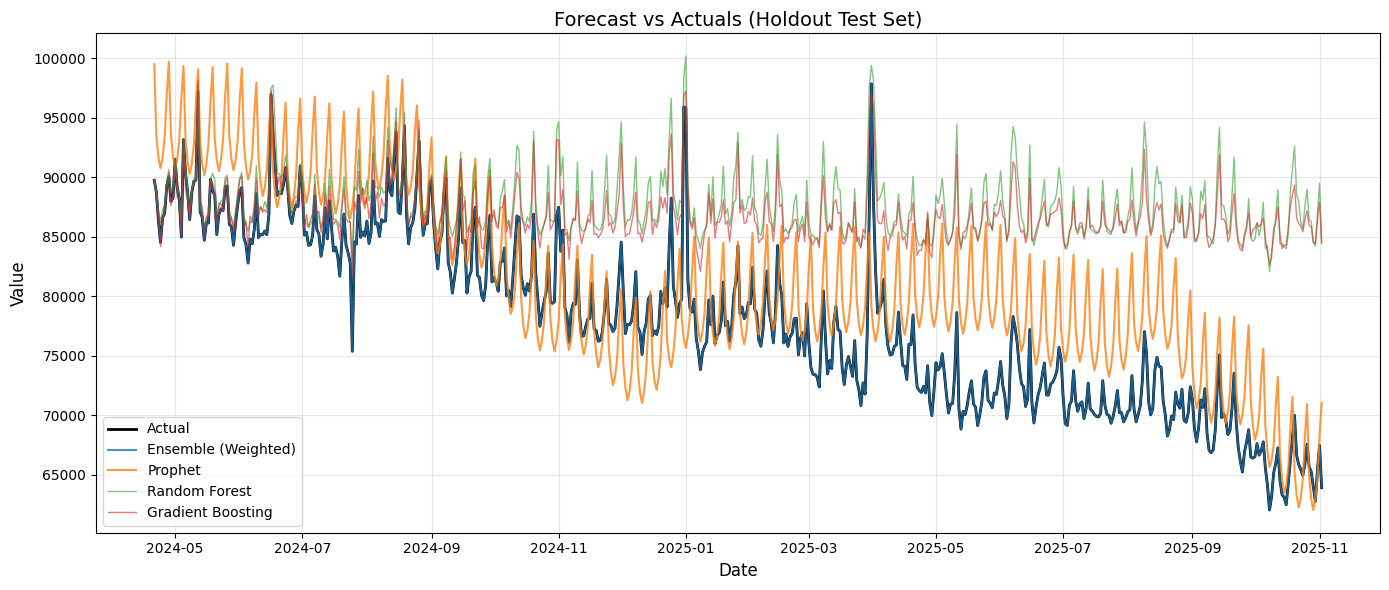

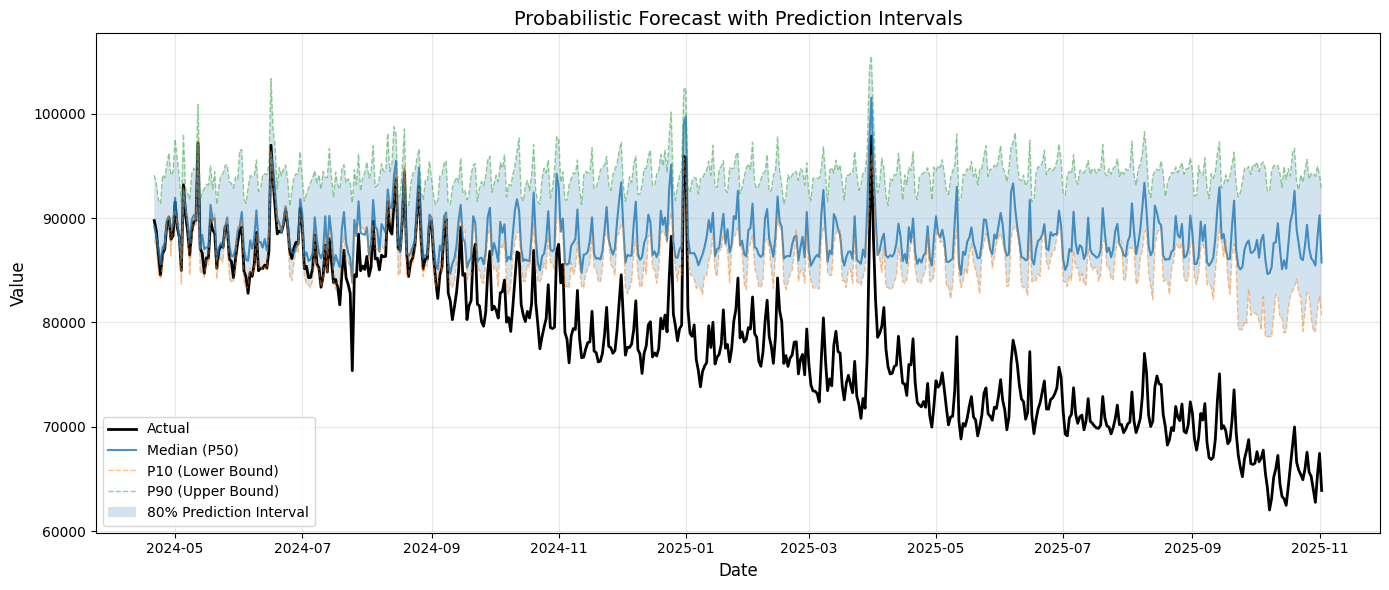

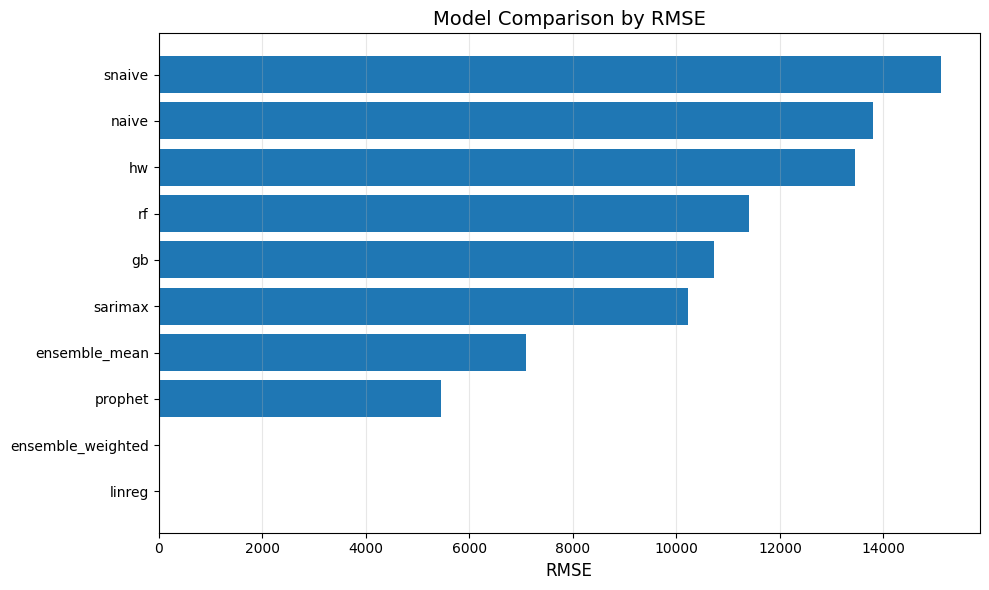

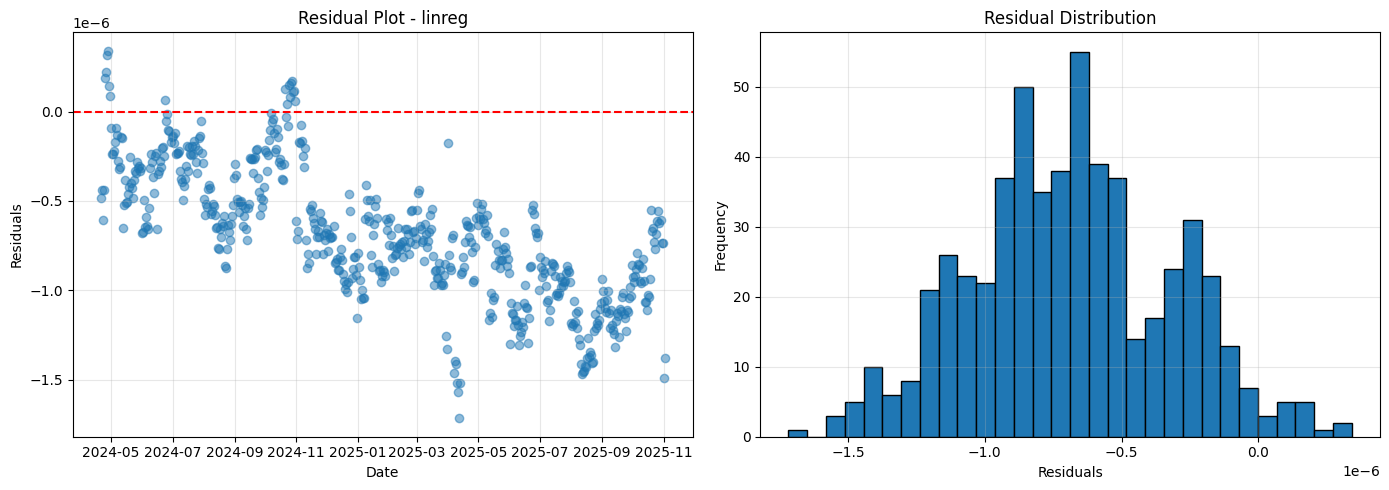


Results saved:
  - holdout_forecasts_improved.csv
  - model_scores_improved.csv


In [44]:
# === Comprehensive Evaluation ===
# Put together a comparison DataFrame
out = test[[test.columns[0], target_col]].copy()
out = out.rename(columns={test.columns[0]: "ds", target_col: "y"})
out["naive"] = yhat_naive
out["snaive"] = yhat_snaive
out["hw"] = np.asarray(yhat_hw).reshape(-1)
out["sarimax"] = np.asarray(yhat_sarimax).reshape(-1)
out["linreg"] = yhat_lin
out["rf"] = yhat_rf
out["gb"] = yhat_gb  # Gradient Boosting
out["ensemble_mean"] = yhat_ens_mean
out["ensemble_weighted"] = yhat_ens_weighted
out["p10"] = q10
out["p50"] = q50
out["p90"] = q90

# Add Prophet if available
if PROPHET_AVAILABLE and yhat_prophet is not None:
    out["prophet"] = np.asarray(yhat_prophet).reshape(-1)

# Metrics function
def metrics(y, yhat):
    return {
        "MAE": mean_absolute_error(y, yhat),
        "RMSE": rmse(y, yhat),
        "MAPE(%)": mape(y, yhat),
    }

# Calculate metrics for all models
model_cols = ["naive", "snaive", "hw", "sarimax", "linreg", "rf", "gb", "ensemble_mean", "ensemble_weighted"]
if PROPHET_AVAILABLE and yhat_prophet is not None:
    model_cols.append("prophet")

scores = {}
for col in model_cols:
    if col in out.columns:
        scores[col] = metrics(out["y"], out[col])

scores_df = pd.DataFrame(scores).T.sort_values("RMSE")
print("=" * 60)
print("EVALUATION METRICS (lower is better)")
print("=" * 60)
display(scores_df)

# Highlight best model
best_model = scores_df.index[0]
print(f"\nBest performing model: {best_model}")
print(f"  MAE:  {scores_df.loc[best_model, 'MAE']:.2f}")
print(f"  RMSE: {scores_df.loc[best_model, 'RMSE']:.2f}")
print(f"  MAPE: {scores_df.loc[best_model, 'MAPE(%)']:.2f}%")

# Coverage for probabilistic interval [p10, p90]
try:
    cov = coverage(out["y"], out["p10"], out["p90"])
    print(f"\nProbabilistic Forecast:")
    print(f"  Empirical coverage for [p10, p90]: {cov:.1%}")
    print(f"  (Target coverage: 80%)")
except Exception as e:
    print("Coverage calculation failed:", e)

# === Visualization 1: Predictions vs Truth ===
plt.figure(figsize=(14, 6))
plt.plot(out["ds"], out["y"], label="Actual", linewidth=2, color='black')
plt.plot(out["ds"], out["ensemble_weighted"], label="Ensemble (Weighted)", linewidth=1.5, alpha=0.8)
if PROPHET_AVAILABLE and yhat_prophet is not None:
    plt.plot(out["ds"], out["prophet"], label="Prophet", linewidth=1.5, alpha=0.8)
plt.plot(out["ds"], out["rf"], label="Random Forest", linewidth=1, alpha=0.6)
plt.plot(out["ds"], out["gb"], label="Gradient Boosting", linewidth=1, alpha=0.6)
plt.title("Forecast vs Actuals (Holdout Test Set)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# === Visualization 2: Probabilistic Fan Chart ===
plt.figure(figsize=(14, 6))
plt.plot(out["ds"], out["y"], label="Actual", linewidth=2, color='black')
plt.plot(out["ds"], out["p50"], label="Median (P50)", linewidth=1.5, alpha=0.8)
plt.plot(out["ds"], out["p10"], label="P10 (Lower Bound)", linewidth=1, alpha=0.5, linestyle='--')
plt.plot(out["ds"], out["p90"], label="P90 (Upper Bound)", linewidth=1, alpha=0.5, linestyle='--')
plt.fill_between(out["ds"], out["p10"], out["p90"], alpha=0.2, label="80% Prediction Interval")
plt.title("Probabilistic Forecast with Prediction Intervals", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# === Visualization 3: Model Comparison (RMSE) ===
plt.figure(figsize=(10, 6))
scores_plot = scores_df.sort_values("RMSE", ascending=True)
plt.barh(scores_plot.index, scores_plot["RMSE"])
plt.xlabel("RMSE", fontsize=12)
plt.title("Model Comparison by RMSE", fontsize=14)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# === Visualization 4: Residual Analysis for Best Model ===
residuals = out["y"] - out[best_model]
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(out["ds"], residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title(f"Residual Plot - {best_model}", fontsize=12)
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, edgecolor='black')
plt.title("Residual Distribution", fontsize=12)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save outputs
out_path_csv = "holdout_forecasts_improved.csv"
scores_path_csv = "model_scores_improved.csv"
out.to_csv(out_path_csv, index=False)
scores_df.to_csv(scores_path_csv)

print(f"\nResults saved:")
print(f"  - {out_path_csv}")
print(f"  - {scores_path_csv}")